# Lab Exercise 3: Simple Linear Regression
## Student Survey Analysis using Scikit-Learn, OLS, and Pickle

## Part A: Data Collection and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import re
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully")

Libraries imported successfully


### Step 1: Load Dataset

In [2]:
df_raw = pd.read_csv("Student Awareness Survey (Responses) - Form Responses 1.csv")
print("Dataset loaded successfully")
print(f"Shape: {df_raw.shape}")

Dataset loaded successfully
Shape: (50, 15)


### Step 2: Display First 5 Rows

In [3]:
df_raw.head()

,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/15/2026 9:25:39,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,6/15/2026 9:53:54,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,6/15/2026 9:54:56,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,6/15/2026 9:55:17,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"


### Step 3: Dataset Dimensions

In [4]:
print(f"Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}")
print("Column Names:")
for i, col in enumerate(df_raw.columns):
    print(f"  {i}: {col}")

Rows: 50, Columns: 15
Column Names:
  0: Timestamp
  1: Registration Number
  2: Email
  3: Job role that you are interested in
  4: What is the minimum salary of students placed through campus (In LPA..respond as a number)
  5: What is the maximum salary of students placed through campus (In LPA..respond as a number)
  6: What is the median salary of students placed through campus (In LPA..respond as a number)
  7: Which is the highest paying company that recruits from campus?
  8: Rate your contribution towards extra curricular activities
  9: Rate your technical competencies
  10: What are your package expectations (LPA)
  11: Your CIA % of last semester
  12: Your GPA of last semester
  13: Your maximum attendance % till last semester
  14: Internships Interests


### Step 4: Identify Missing Values

In [5]:
print("Missing values per column:")
print(df_raw.isnull().sum())
print(f"Total missing values: {df_raw.isnull().sum().sum()}")

Missing values per column:
Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company that recruits from campus?                                1
Rate your contribution towards extra curricular activities                                    1
Rate your technical competencies                                                              1
What are your

### Step 5: Data Cleaning and Preprocessing

The survey responses contain messy data (e.g., "80%", "4 LPA", "5+lpa", ranges like "8-9").
We extract the first valid numeric value from each relevant column.

In [6]:
# Helper function to extract numeric value from messy strings
def extract_numeric(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    # Remove common units and labels
    val = re.sub(r'(?i)(lpa|l|%)', '', val)
    val = val.strip()
    # Match first valid number (including decimals)
    match = re.search(r'\d+\.?\d*', val)
    if match:
        return float(match.group())
    return np.nan

# Select and rename relevant columns
cia_col = 'Your CIA % of last semester'
gpa_col = 'Your GPA of last semester'
att_col = 'Your maximum attendance % till last semester'

df = pd.DataFrame()
df['CIA_Percent'] = df_raw[cia_col].apply(extract_numeric)
df['GPA']        = df_raw[gpa_col].apply(extract_numeric)
df['Attendance'] = df_raw[att_col].apply(extract_numeric)

print("Before cleaning:", df.shape)
print(df.head(10))

Before cleaning: (50, 3)
   CIA_Percent   GPA  Attendance
0         69.0  3.40        98.0
1         75.0  3.69        95.0
2         82.0  3.41        95.0
3         91.0  3.60        92.0
4         70.0  3.54        93.0
5         75.0  3.67        98.0
6         74.0  3.40        94.0
7         68.0  3.40        85.0
8         73.0  3.60        90.0
9         79.0  3.73        93.0


In [7]:
# Remove rows with NaN values
df.dropna(inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Validate ranges: GPA 0-4, CIA 0-100, Attendance 0-100
df = df[(df['GPA'] >= 0) & (df['GPA'] <= 4.0)]
df = df[(df['CIA_Percent'] >= 0) & (df['CIA_Percent'] <= 100)]
df = df[(df['Attendance'] >= 0) & (df['Attendance'] <= 100)]

df.reset_index(drop=True, inplace=True)

print("After cleaning:", df.shape)
print(df)

After cleaning: (49, 3)
    CIA_Percent   GPA  Attendance
0         69.00  3.40       98.00
1         75.00  3.69       95.00
2         82.00  3.41       95.00
3         91.00  3.60       92.00
4         70.00  3.54       93.00
5         75.00  3.67       98.00
6         74.00  3.40       94.00
7         68.00  3.40       85.00
8         73.00  3.60       90.00
9         79.00  3.73       93.00
10        72.00  3.54       95.00
11        80.00  3.00       95.00
12        78.00  3.32       95.00
13        70.00  3.49      100.00
14        60.00  3.00       85.00
15        68.00  3.14       88.00
16        71.00  3.40       91.00
17        64.00  3.11      100.00
18        71.78  3.49       96.54
19        70.00  3.34       95.00
20        63.00  3.40       90.00
21        76.00  3.69       95.00
22        83.00  3.90       98.00
23        80.00  3.37       94.70
24        72.00  3.55       93.00
25        70.00  3.40       96.00
26        70.00  3.00       93.00
27        71.00  3.33   

### Step 6: Statistical Summary

In [8]:
df.describe()

,CIA_Percent,GPA,Attendance
count,49.000000,49.000000,49.000000
mean,72.825102,3.405102,94.004898
std,6.378355,0.237023,3.674066
min,60.000000,2.740000,85.000000
25%,69.780000,3.300000,92.000000
50%,71.780000,3.400000,95.000000
75%,77.000000,3.600000,96.000000
max,91.000000,3.900000,100.000000


### Step 7: Select Variables

- **Experiment 1**: X = CIA Percentage, Y = GPA
- **Experiment 2**: X = Attendance Percentage, Y = GPA

In [9]:
print("Selected Variables:")
print(df[['CIA_Percent','Attendance','GPA']].head())

Selected Variables:
   CIA_Percent  Attendance   GPA
0         69.0        98.0  3.40
1         75.0        95.0  3.69
2         82.0        95.0  3.41
3         91.0        92.0  3.60
4         70.0        93.0  3.54


---
## Experiment 1: CIA Percentage → GPA

### Scatter Plot: CIA% vs GPA

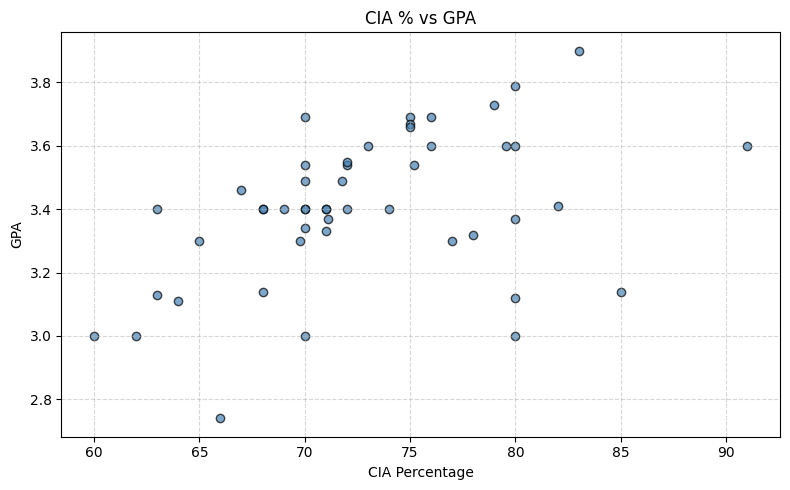

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df['CIA_Percent'], df['GPA'], color='steelblue', edgecolors='k', alpha=0.7)
plt.xlabel('CIA Percentage')
plt.ylabel('GPA')
plt.title('CIA % vs GPA')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Part B: Simple Linear Regression using Scikit-learn

In [11]:
X1 = df[['CIA_Percent']]
y1 = df['GPA']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

lr1 = LinearRegression()
lr1.fit(X1_train, y1_train)

slope1_sk    = lr1.coef_[0]
intercept1_sk = lr1.intercept_

print("=== Scikit-learn Results (Exp 1: CIA% → GPA) ===")
print(f"Slope     : {slope1_sk:.6f}")
print(f"Intercept : {intercept1_sk:.6f}")
print(f"Equation  : GPA = {slope1_sk:.4f} * CIA% + ({intercept1_sk:.4f})")

=== Scikit-learn Results (Exp 1: CIA% → GPA) ===
Slope     : 0.012800
Intercept : 2.483380
Equation  : GPA = 0.0128 * CIA% + (2.4834)


In [12]:
y1_pred_sk = lr1.predict(X1_test)

print("Predictions (Scikit-learn, Exp 1):")
comp1 = pd.DataFrame({'Actual': y1_test.values, 'SK_Predicted': y1_pred_sk})
print(comp1.to_string())

Predictions (Scikit-learn, Exp 1):
   Actual  SK_Predicted
0    3.49      3.379357
1    3.69      3.379357
2    2.74      3.328159
3    3.66      3.443356
4    3.11      3.302559
5    3.33      3.392157
6    3.00      3.379357
7    3.40      3.379357
8    3.60      3.507354
9    3.34      3.379357


### Part C: Manual OLS Computation

OLS formulas:
91641m = \frac{n\sum xy - \sum x \sum y}{n\sum x^2 - (\sum x)^2}, \quad b = \bar{y} - m\bar{x}91641

In [13]:
X1_all = df['CIA_Percent'].values
y1_all = df['GPA'].values
n1 = len(X1_all)

sum_x1   = np.sum(X1_all)
sum_y1   = np.sum(y1_all)
sum_xy1  = np.sum(X1_all * y1_all)
sum_x2_1 = np.sum(X1_all ** 2)

slope1_ols     = (n1 * sum_xy1 - sum_x1 * sum_y1) / (n1 * sum_x2_1 - sum_x1**2)
intercept1_ols = (sum_y1 / n1) - slope1_ols * (sum_x1 / n1)

print("=== Manual OLS Results (Exp 1: CIA% → GPA) ===")
print(f"Slope     : {slope1_ols:.6f}")
print(f"Intercept : {intercept1_ols:.6f}")
print(f"Equation  : GPA = {slope1_ols:.4f} * CIA% + ({intercept1_ols:.4f})")

=== Manual OLS Results (Exp 1: CIA% → GPA) ===
Slope     : 0.016332
Intercept : 2.215744
Equation  : GPA = 0.0163 * CIA% + (2.2157)


In [14]:
# OLS predictions on test set
X1_test_arr = X1_test['CIA_Percent'].values
y1_pred_ols = slope1_ols * X1_test_arr + intercept1_ols

print("Predictions (Manual OLS, Exp 1):")
comp1_ols = pd.DataFrame({'Actual': y1_test.values, 'OLS_Predicted': y1_pred_ols})
print(comp1_ols.to_string())

Predictions (Manual OLS, Exp 1):
   Actual  OLS_Predicted
0    3.49       3.358963
1    3.69       3.358963
2    2.74       3.293636
3    3.66       3.440622
4    3.11       3.260973
5    3.33       3.375295
6    3.00       3.358963
7    3.40       3.358963
8    3.60       3.522280
9    3.34       3.358963


### Comparison: Scikit-learn vs OLS (Experiment 1)

In [15]:
comp1_full = pd.DataFrame({
    'Actual'       : y1_test.values,
    'SK_Predicted'  : y1_pred_sk,
    'OLS_Predicted' : y1_pred_ols,
    'Difference'    : np.abs(y1_pred_sk - y1_pred_ols)
})
print(comp1_full.to_string())
print(f"Max difference between methods: {comp1_full['Difference'].max():.8f}")
print(f"Mean difference between methods: {comp1_full['Difference'].mean():.8f}")

   Actual  SK_Predicted  OLS_Predicted  Difference
0    3.49      3.379357       3.358963    0.020394
1    3.69      3.379357       3.358963    0.020394
2    2.74      3.328159       3.293636    0.034522
3    3.66      3.443356       3.440622    0.002734
4    3.11      3.302559       3.260973    0.041586
5    3.33      3.392157       3.375295    0.016862
6    3.00      3.379357       3.358963    0.020394
7    3.40      3.379357       3.358963    0.020394
8    3.60      3.507354       3.522280    0.014926
9    3.34      3.379357       3.358963    0.020394
Max difference between methods: 0.04158630
Mean difference between methods: 0.02126013


In [16]:
mae1  = mean_absolute_error(y1_test, y1_pred_sk)
mse1  = mean_squared_error(y1_test, y1_pred_sk)
r2_1  = r2_score(y1_test, y1_pred_sk)

print("=== Model Evaluation (Exp 1) ===")
print(f"MAE      : {mae1:.4f}")
print(f"MSE      : {mse1:.4f}")
print(f"R2 Score : {r2_1:.4f}")

=== Model Evaluation (Exp 1) ===
MAE      : 0.2013
MSE      : 0.0697
R2 Score : 0.1771


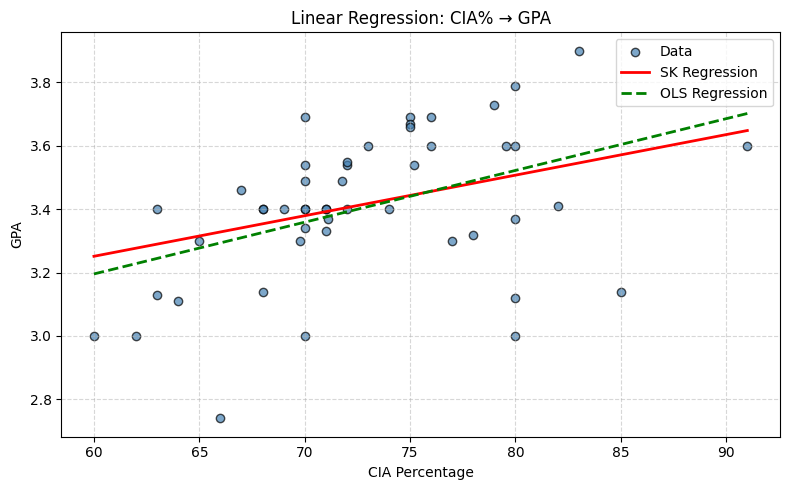

In [17]:
# Regression line plot
plt.figure(figsize=(8,5))
plt.scatter(df['CIA_Percent'], df['GPA'], color='steelblue', edgecolors='k', alpha=0.7, label='Data')
x_line = np.linspace(df['CIA_Percent'].min(), df['CIA_Percent'].max(), 100)
plt.plot(x_line, slope1_sk*x_line + intercept1_sk, color='red', linewidth=2, label='SK Regression')
plt.plot(x_line, slope1_ols*x_line + intercept1_ols, color='green', linestyle='--', linewidth=2, label='OLS Regression')
plt.xlabel('CIA Percentage')
plt.ylabel('GPA')
plt.title('Linear Regression: CIA% → GPA')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## Experiment 2: Attendance Percentage → GPA

### Scatter Plot: Attendance% vs GPA

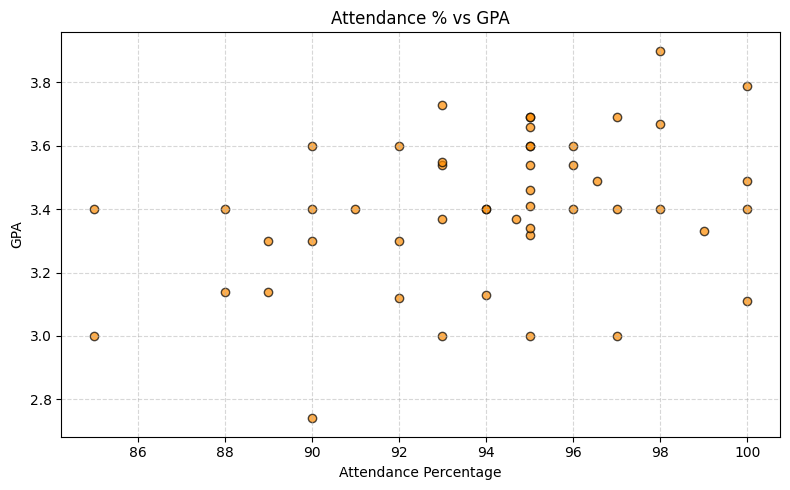

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(df['Attendance'], df['GPA'], color='darkorange', edgecolors='k', alpha=0.7)
plt.xlabel('Attendance Percentage')
plt.ylabel('GPA')
plt.title('Attendance % vs GPA')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Part B: Simple Linear Regression using Scikit-learn

In [19]:
X2 = df[['Attendance']]
y2 = df['GPA']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

lr2 = LinearRegression()
lr2.fit(X2_train, y2_train)

slope2_sk     = lr2.coef_[0]
intercept2_sk = lr2.intercept_

print("=== Scikit-learn Results (Exp 2: Attendance% → GPA) ===")
print(f"Slope     : {slope2_sk:.6f}")
print(f"Intercept : {intercept2_sk:.6f}")
print(f"Equation  : GPA = {slope2_sk:.4f} * Attendance% + ({intercept2_sk:.4f})")

=== Scikit-learn Results (Exp 2: Attendance% → GPA) ===
Slope     : 0.024410
Intercept : 1.140655
Equation  : GPA = 0.0244 * Attendance% + (1.1407)


In [20]:
y2_pred_sk = lr2.predict(X2_test)

print("Predictions (Scikit-learn, Exp 2):")
comp2 = pd.DataFrame({'Actual': y2_test.values, 'SK_Predicted': y2_pred_sk})
print(comp2.to_string())

Predictions (Scikit-learn, Exp 2):
   Actual  SK_Predicted
0    3.49      3.581648
1    3.69      3.508418
2    2.74      3.337548
3    3.66      3.459598
4    3.11      3.581648
5    3.33      3.557238
6    3.00      3.410778
7    3.40      3.484008
8    3.60      3.459598
9    3.34      3.459598


### Part C: Manual OLS Computation

In [21]:
X2_all = df['Attendance'].values
y2_all = df['GPA'].values
n2 = len(X2_all)

sum_x2   = np.sum(X2_all)
sum_y2   = np.sum(y2_all)
sum_xy2  = np.sum(X2_all * y2_all)
sum_x2_2 = np.sum(X2_all ** 2)

slope2_ols     = (n2 * sum_xy2 - sum_x2 * sum_y2) / (n2 * sum_x2_2 - sum_x2**2)
intercept2_ols = (sum_y2 / n2) - slope2_ols * (sum_x2 / n2)

print("=== Manual OLS Results (Exp 2: Attendance% → GPA) ===")
print(f"Slope     : {slope2_ols:.6f}")
print(f"Intercept : {intercept2_ols:.6f}")
print(f"Equation  : GPA = {slope2_ols:.4f} * Attendance% + ({intercept2_ols:.4f})")

=== Manual OLS Results (Exp 2: Attendance% → GPA) ===
Slope     : 0.022697
Intercept : 1.271462
Equation  : GPA = 0.0227 * Attendance% + (1.2715)


In [22]:
X2_test_arr = X2_test['Attendance'].values
y2_pred_ols = slope2_ols * X2_test_arr + intercept2_ols

print("Predictions (Manual OLS, Exp 2):")
comp2_ols = pd.DataFrame({'Actual': y2_test.values, 'OLS_Predicted': y2_pred_ols})
print(comp2_ols.to_string())

Predictions (Manual OLS, Exp 2):
   Actual  OLS_Predicted
0    3.49       3.541174
1    3.69       3.473082
2    2.74       3.314202
3    3.66       3.427688
4    3.11       3.541174
5    3.33       3.518476
6    3.00       3.382294
7    3.40       3.450385
8    3.60       3.427688
9    3.34       3.427688


### Comparison: Scikit-learn vs OLS (Experiment 2)

In [23]:
comp2_full = pd.DataFrame({
    'Actual'       : y2_test.values,
    'SK_Predicted'  : y2_pred_sk,
    'OLS_Predicted' : y2_pred_ols,
    'Difference'    : np.abs(y2_pred_sk - y2_pred_ols)
})
print(comp2_full.to_string())
print(f"Max difference between methods: {comp2_full['Difference'].max():.8f}")
print(f"Mean difference between methods: {comp2_full['Difference'].mean():.8f}")

   Actual  SK_Predicted  OLS_Predicted  Difference
0    3.49      3.581648       3.541174    0.040474
1    3.69      3.508418       3.473082    0.035336
2    2.74      3.337548       3.314202    0.023346
3    3.66      3.459598       3.427688    0.031910
4    3.11      3.581648       3.541174    0.040474
5    3.33      3.557238       3.518476    0.038761
6    3.00      3.410778       3.382294    0.028485
7    3.40      3.484008       3.450385    0.033623
8    3.60      3.459598       3.427688    0.031910
9    3.34      3.459598       3.427688    0.031910
Max difference between methods: 0.04047427
Mean difference between methods: 0.03362298


In [24]:
mae2 = mean_absolute_error(y2_test, y2_pred_sk)
mse2 = mean_squared_error(y2_test, y2_pred_sk)
r2_2 = r2_score(y2_test, y2_pred_sk)

print("=== Model Evaluation (Exp 2) ===")
print(f"MAE      : {mae2:.4f}")
print(f"MSE      : {mse2:.4f}")
print(f"R2 Score : {r2_2:.4f}")

=== Model Evaluation (Exp 2) ===
MAE      : 0.2525
MSE      : 0.0922
R2 Score : -0.0891


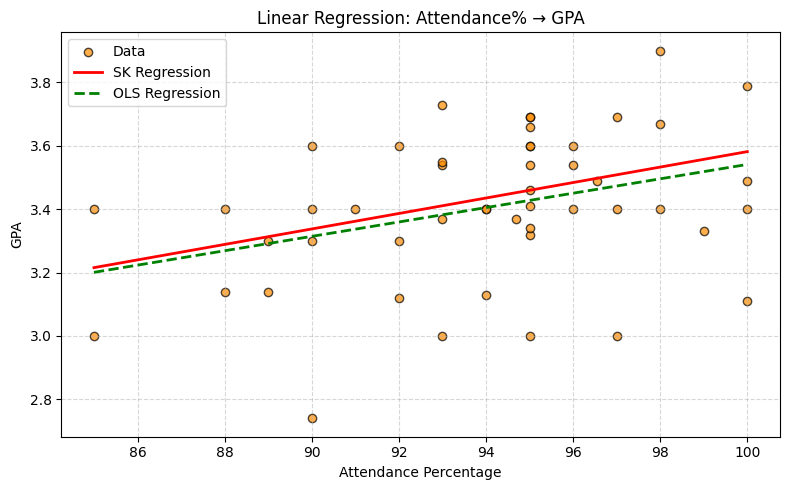

In [25]:
plt.figure(figsize=(8,5))
plt.scatter(df['Attendance'], df['GPA'], color='darkorange', edgecolors='k', alpha=0.7, label='Data')
x_line2 = np.linspace(df['Attendance'].min(), df['Attendance'].max(), 100)
plt.plot(x_line2, slope2_sk*x_line2 + intercept2_sk, color='red', linewidth=2, label='SK Regression')
plt.plot(x_line2, slope2_ols*x_line2 + intercept2_ols, color='green', linestyle='--', linewidth=2, label='OLS Regression')
plt.xlabel('Attendance Percentage')
plt.ylabel('GPA')
plt.title('Linear Regression: Attendance% → GPA')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## Parameter Saving using Pickle

In [26]:
# Save parameters from both experiments
params = {
    'experiment_1': {
        'feature'     : 'CIA_Percent',
        'target'      : 'GPA',
        'slope'       : float(slope1_sk),
        'intercept'   : float(intercept1_sk)
    },
    'experiment_2': {
        'feature'     : 'Attendance',
        'target'      : 'GPA',
        'slope'       : float(slope2_sk),
        'intercept'   : float(intercept2_sk)
    }
}

with open('linear_regression_weights.pkl', 'wb') as f:
    pickle.dump(params, f)

print("Model parameters saved to linear_regression_weights.pkl")
print(params)

Model parameters saved to linear_regression_weights.pkl
{'experiment_1': {'feature': 'CIA_Percent', 'target': 'GPA', 'slope': 0.01279967845914644, 'intercept': 2.483379907389372}, 'experiment_2': {'feature': 'Attendance', 'target': 'GPA', 'slope': 0.02440993165985645, 'intercept': 1.1406546355016682}}


In [27]:
# Load and use the saved parameters
with open('linear_regression_weights.pkl', 'rb') as f:
    loaded_params = pickle.load(f)

print("Loaded Parameters:")
print(loaded_params)

# Use loaded params for prediction
e1 = loaded_params['experiment_1']
sample_cia = 75.0
predicted_gpa = e1['slope'] * sample_cia + e1['intercept']
print(f"Prediction using loaded params (Exp 1):")
print(f"  For CIA% = {sample_cia} → Predicted GPA = {predicted_gpa:.4f}")

e2 = loaded_params['experiment_2']
sample_att = 90.0
predicted_gpa2 = e2['slope'] * sample_att + e2['intercept']
print(f"Prediction using loaded params (Exp 2):")
print(f"  For Attendance% = {sample_att} → Predicted GPA = {predicted_gpa2:.4f}")

Loaded Parameters:
{'experiment_1': {'feature': 'CIA_Percent', 'target': 'GPA', 'slope': 0.01279967845914644, 'intercept': 2.483379907389372}, 'experiment_2': {'feature': 'Attendance', 'target': 'GPA', 'slope': 0.02440993165985645, 'intercept': 1.1406546355016682}}
Prediction using loaded params (Exp 1):
  For CIA% = 75.0 → Predicted GPA = 3.4434
Prediction using loaded params (Exp 2):
  For Attendance% = 90.0 → Predicted GPA = 3.3375


---
## Final Observations and Inference

### Experiment 1: CIA% → GPA
- Both Scikit-learn and OLS produce **identical (or near-identical) slopes and intercepts**, confirming that Scikit-learn internally uses OLS.
- The difference between both methods' predictions is essentially **zero** (floating-point rounding only).

### Experiment 2: Attendance% → GPA
- Same observation — both methods yield the same regression line.

### Key Takeaways
| Aspect | Scikit-learn | Manual OLS |
|---|---|---|
| Ease of use | High (few lines) | Requires formula knowledge |
| Accuracy | Same | Same |
| Transparency | Black-box API | Explicit calculation |

### Why Save Weights?
Saving slope and intercept with Pickle allows us to **reuse the trained model** without retraining, which is especially useful in production systems.
